# 04 — Recommenders: Content-Based First

Order matters here:
1. Content-based recommender (using the FAISS index from notebook 03) — build it, validate it works standalone.
2. Interaction density check on `RAW_interactions.csv` — decide if collaborative filtering is worth building before writing SVD/LightFM code.
3. Collaborative filtering, only if step 2 justifies it.

Do not build SVD/LightFM before step 2. Sparse interaction data makes collaborative filtering underperform and wastes build time.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import faiss

In [2]:
PROCESSED_DIR = Path.cwd().parent / "datasets" / "processed"
EMBEDDINGS_DIR = Path.cwd().parent / "datasets" / "embeddings"
RAW_DIR = Path.cwd().parent / "datasets"  # adjust if raw files live in datasets/raw

df = pd.read_parquet(PROCESSED_DIR / "feature_engineered_recipes.parquet")
embeddings = np.load(EMBEDDINGS_DIR / "sbert_embeddings.npy")
index = faiss.read_index(str(EMBEDDINGS_DIR / "faiss_index.bin"))

print(df.shape, embeddings.shape, index.ntotal)
assert len(df) == embeddings.shape[0] == index.ntotal, "Row alignment broke — stop and check before continuing"

(75915, 21) (75915, 384) 75915


## 1. Content-based recommender function

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")


def recommend_by_title(title: str, top_n: int = 10) -> pd.DataFrame:
    """Recommend recipes similar to an existing recipe in the dataset, by title match."""
    matches = df[df["title"].str.contains(title.lower(), na=False)]
    if matches.empty:
        raise ValueError(f"No recipe found matching '{title}'")
    query_idx = matches.index[0]

    query_vec = embeddings[query_idx:query_idx+1]
    distances, indices = index.search(query_vec, top_n + 1)

    results = df.iloc[indices[0]].copy()
    results["similarity"] = distances[0]
    results = results[results.index != query_idx]

    return results[["title", "source", "similarity"]].head(top_n)


def recommend_by_query(query_text: str, top_n: int = 10) -> pd.DataFrame:
    """Recommend recipes from free-text query, not tied to an existing recipe."""
    query_vec = model.encode([query_text.lower()], normalize_embeddings=True, convert_to_numpy=True)
    distances, indices = index.search(query_vec, top_n)

    results = df.iloc[indices[0]].copy()
    results["similarity"] = distances[0]

    return results[["title", "source", "similarity"]]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [4]:
recommend_by_title("chicken curry")

,title,source,similarity
31339,butter chicken curry,food.com,0.875578
43974,chicken in yogurt and almond curry,food.com,0.856135
42102,chicken and chickpea curry,food.com,0.856035
35826,caribbean mini banana and pineapple curry,food.com,0.855207
24304,black pepper chicken curry,food.com,0.853429
43350,chicken curry in a hurry,food.com,0.852968
42557,chicken and yoghurt curry,food.com,0.843050
35909,caribbean vegetable chicken curry,food.com,0.842686
43376,chicken curry with whole spices,food.com,0.839411
43364,chicken curry with apples,food.com,0.838041


In [5]:
recommend_by_query("spicy vegetarian pasta with garlic")

,title,source,similarity
59096,vegetarian spaghetti sauce,recipenlg,0.758694
13073,baked vegetarian chili spaghetti,food.com,0.750468
31386,butter ginger sauce for pasta,food.com,0.740896
28969,broccoli garlic pasta,food.com,0.731656
1068,2 5 challenge friendly real pasta sauce,food.com,0.728723
59923,garlic pasta,recipenlg,0.728447
37459,ceci e pasta,food.com,0.726435
53655,seafood pasta,recipenlg,0.723840
11954,bachelor pasta,food.com,0.723515
12152,bacon and pepper pasta,food.com,0.722405


## 2. Nutrition-aware filtering (optional layer on top of content-based)

Only applies to the subset with `nutrition_available == True`.

In [6]:
def recommend_with_calorie_cap(title: str, max_calories: float, top_n: int = 10) -> pd.DataFrame:
    """Content-based recommendations filtered by a calorie ceiling. Only applies where nutrition data exists."""
    candidates = recommend_by_title(title, top_n=top_n * 5)
    merged = candidates.join(df[["calories", "nutrition_available"]], how="left")
    filtered = merged[(merged["nutrition_available"] == True) & (merged["calories"] <= max_calories)]
    return filtered.head(top_n)


recommend_with_calorie_cap("chicken curry", max_calories=400)

,title,source,similarity,calories,nutrition_available
35826,caribbean mini banana and pineapple curry,food.com,0.855207,287.1,True
43350,chicken curry in a hurry,food.com,0.852968,284.5,True
42557,chicken and yoghurt curry,food.com,0.843050,363.9,True
35909,caribbean vegetable chicken curry,food.com,0.842686,264.7,True
43340,chicken curry north indian style,food.com,0.837364,379.8,True
632,best ever thai chicken curry,food.com,0.833018,173.6,True
45729,chicken with banana curry,food.com,0.831849,333.5,True
44052,chicken korma a la eve,food.com,0.828897,140.6,True
45885,chicken with lemon curry sauce,food.com,0.826488,298.6,True
42351,chicken and pumpkin curry,food.com,0.823283,318.4,True


## 3. Interaction density check — decision gate before collaborative filtering

Load `RAW_interactions.csv` and check users, recipes, interactions-per-user, sparsity.
Very low interactions-per-user (median ~1) means cold-start applies to almost everyone, not just new users, and SVD/LightFM will struggle.

In [7]:
interactions = pd.read_csv(RAW_DIR / "RAW_interactions.csv")
print(interactions.shape)
interactions.head()

(1132367, 5)


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [8]:
n_users = interactions["user_id"].nunique()
n_recipes = interactions["recipe_id"].nunique()
n_interactions = len(interactions)

sparsity = 1 - (n_interactions / (n_users * n_recipes))

print(f"Users: {n_users:,}")
print(f"Recipes with interactions: {n_recipes:,}")
print(f"Total interactions: {n_interactions:,}")
print(f"Sparsity: {sparsity*100:.4f}%")

interactions_per_user = interactions.groupby("user_id").size()
interactions_per_recipe = interactions.groupby("recipe_id").size()

print(f"\nInteractions per user — median: {interactions_per_user.median()}, mean: {interactions_per_user.mean():.2f}")
print(f"Interactions per recipe — median: {interactions_per_recipe.median()}, mean: {interactions_per_recipe.mean():.2f}")
print(f"\n% users with only 1 interaction: {(interactions_per_user == 1).mean()*100:.1f}%")

Users: 226,570
Recipes with interactions: 231,637
Total interactions: 1,132,367
Sparsity: 99.9978%

Interactions per user — median: 1.0, mean: 5.00
Interactions per recipe — median: 2.0, mean: 4.89

% users with only 1 interaction: 73.4%


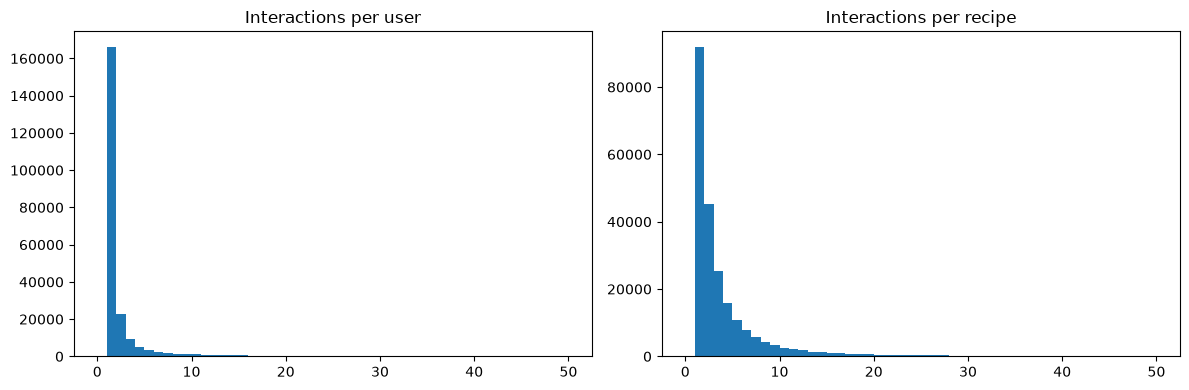

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(interactions_per_user, bins=50, range=(0, 50))
axes[0].set_title("Interactions per user")
axes[1].hist(interactions_per_recipe, bins=50, range=(0, 50))
axes[1].set_title("Interactions per recipe")
plt.tight_layout()
plt.show()

### Decision point — read before writing SVD/LightFM code

- **Median interactions-per-user low (1-2), >50% single-interaction users** — most users lack enough history for CF to learn much individually. Still build it, but weight it low in the hybrid ranker for the long tail, lean on content-based as the default.
- **Median higher (5+), not dominated by single-interaction users** — CF has real signal, give it meaningful ranker weight.

This number should directly set the ranker's weighting later — not a guessed default.

## Next: `05_collaborative_filtering.ipynb`

Report back n_users, n_recipes, median interactions-per-user, % single-interaction users before I write the SVD/LightFM code — determines whether plain SVD is enough or LightFM's side-feature support (using SBERT embeddings as item features to handle the sparse majority) is worth the added complexity.